## **load data**

## **combine datasets**

In [ ]:
import glob
import numpy as np
from PIL import Image

images = []
labels = []
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 
          'jazz', 'metal', 'pop', 'reggae', 'rock']

for genre in genres:
    # Find all .png files in the genre folder
    path = f'/Users/sophiekim/Desktop/1_spring/ds 6050/Data/images_original/{genre}/*.png'
    for file in glob.glob(path):
        img = Image.open(file).convert('RGB')
        img = img.resize((128, 128)) # Optional: resize for memory efficiency
        images.append(np.array(img))
        labels.append(genre)

# Convert to a single numpy array
X = np.array(images)

In [6]:
# 3. Convert to Numpy and Normalize
X = np.array(X) / 255.0  # Scale pixels to [0, 1]

In [7]:
print(X)

[[[[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  ...

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]]


 [[[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  ...

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]

  [[1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   ...
   [1

In [8]:
# Check the shape: (Number of images, Height, Width, Channels)
print("Shape:", X.shape) 

# Check if there is anything OTHER than white (255)
print("Min value:", X.min()) 
print("Max value:", X.max())
print("Average pixel value:", X.mean())

Shape: (999, 128, 128, 3)
Min value: 0.0
Max value: 1.0
Average pixel value: 0.4843188656417079


In [4]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. Convert strings ('blues', 'rock') to integers (0, 1, 2...)
le = LabelEncoder()
y_integers = le.fit_transform(labels) 

# 2. Convert integers to "One-Hot" vectors
# 'blues' becomes [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
y = to_categorical(y_integers, num_classes=10)

print(f"X shape: {X.shape}") # (1000, 128, 128, 3)
print(f"y shape: {y.shape}") # (1000, 10)

X shape: (999, 128, 128, 3)
y shape: (999, 10)


## **convert audio files to numeric arrays**

## **model 1 - images**

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

In [9]:
# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data ready! Training shape: {X_train.shape}, Labels shape: {y_train.shape}")

Data ready! Training shape: (799, 128, 128, 3), Labels shape: (799, 10)


In [25]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/2, lon/2, 64)

    # CNN block 32 kernels (conv + pool)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/4, lon/4, 32) 

    # CNN block 16 kernels (conv only)
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),             
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dropout(0.4),                   # Balanced dropout
    layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │        25,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,390 (396.05 KB)

 Trainable params: 101,390 (396.05 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.optimizers import Adam


model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy', # Matches our integer y_train
    metrics=['accuracy']
)

In [30]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,          # Stop if val_loss doesn't improve for 5 epochs
    restore_best_weights=True
)


history = model.fit(
    X_train, 
    y_train, 
    epochs=20,              # Increased epochs to see the loss drop
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1               # This gives you the progress bar + loss + accuracy
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.1076 - loss: 2.3101 - val_accuracy: 0.0550 - val_loss: 2.3067
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.1302 - loss: 2.3132 - val_accuracy: 0.0550 - val_loss: 2.3067
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.1089 - loss: 2.3009 - val_accuracy: 0.0550 - val_loss: 2.3067
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.1064 - loss: 2.3112 - val_accuracy: 0.0550 - val_loss: 2.3066
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.1001 - loss: 2.3092 - val_accuracy: 0.0550 - val_loss: 2.3066
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.1089 - loss: 2.3153 - val_accuracy: 0.0550 - val_loss: 2.3066
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.0976 - loss: 2.3226 - val_accuracy: 0.0550 - val_loss: 2.3066
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.1051 - loss: 2.3231 - val_accuracy: 0.

KeyboardInterrupt: 

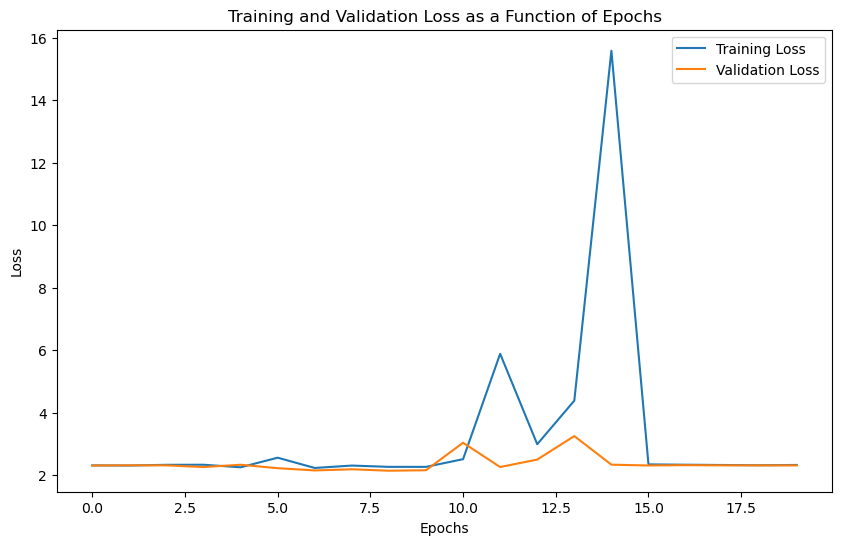

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### **analysis of model 1**

## **model 2 - audio**

### **analysis of model 2**